In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
import spectrum as sp
from matplotlib.patches import Circle
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
hbar=h/(2*np.pi)
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
me=cons.m_e.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
T0=v0**2*mu*mp #temperature unit
rho0=2*G*Mbh/c**2


In [2]:
default_args = {}
default_args['figsize'] = (4,4)
default_args['filename_data'] = '../output/example_free_free_tde.npz'
default_args['filename_plot'] = None
default_args['stokes_q'] = False
default_args['stokes_u'] = False
default_args['stokes_v'] = False
default_args['name'] = None
default_args['frequency_num'] = None
default_args['refinement_level'] = False
default_args['width'] = None
default_args['mass'] = None
default_args['distance'] = None
default_args['axes'] = None
default_args['max_level'] = None
default_args['vmin'] = None
default_args['vmax'] = None
default_args['cmap'] = None
default_args['notex'] = False
default_args['fontsize'] = None

In [3]:
plt.rcParams["figure.figsize"] = (4,4)
plt.rcParams["figure.dpi"] = 100

In [50]:
temp=(100*G*Mbh/c**2)*u.cgs.cm
print(temp)
print(temp.to(u.pc))

44298751141503.734 cm
1.4356247524763523e-05 pc


In [73]:
v0=0.001
mu=0.5
rho0=1.543e-3
P0 = rho0*v0*v0*c*c
print(P0)
print(mu*mp*v0*v0*c*c/kB)

1386779240790.9097
5444097.725001525


In [9]:
(2.998e+07)/c

0.00100002515740406

In [4]:
((288*me*((4.8e-10)**2)*((0.8853)**3)*((4*np.pi)**(4/3))*((5.29e-9)**3)/((3*1.66e-24)**(4/3)))**(5/2))/(15*hbar*hbar*hbar*(np.pi**2)*me)

4.200804832009859e+16

In [7]:
9.478e9/1.158e11

0.08184801381692573

In [19]:
(c*3.335e-08)**2*mu*mp

1.0031875129470097e-18

In [20]:
6.553e6*kB

9.047392897e-10

In [150]:
def j_I(T,nu,ne,ni):
    #1/kBT is like 4.39e13
    #the exponent keeps going to 0
    return (16*np.exp(6)/(3*me*c**3))*np.sqrt(1/me)*np.sqrt(2*np.pi/(3*kB*T))*(ne*ni)*np.exp(-h*nu/(kB*T))*(nu**(-2))

In [151]:
def alpha_I(T,nu,ne,ni):
    return (4*np.exp(6)/(3*me*c*h))*np.sqrt(1/me)*np.sqrt(2*np.pi/(3*kB*T))*ne*ni*(1-np.exp(-h*nu/(kB*T)))*(nu**(-2))

In [178]:
#assuming optically thick
def I_nu(T,nu,ne,ni):
    return (nu**3)*j_I(T,nu,ne,ni)/alpha_I(T,nu,ne,ni)
def nuFnu(T,nu,ne,ni,dist,mass):
    gg_msun = 1.32712440018e26
    rg = gg_msun * mass / c ** 2
    return nu*np.nanmean(I_nu(T,nu,ne,ni))*4*np.pi*((dist*rg)**2)

In [179]:
arguments = {'data_file': '../data/input.cbdisk.out1.01637_float32.athdf', 'quantity': 'rho', 'output_file': './plots/rhoPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
rho = plot_slice.getDataSlice(**arguments)
print(rho.shape)

(768, 512)


In [81]:
arguments = {'data_file': '../data/input.cbdisk.out1.01637_float32.athdf', 'quantity': 'press', 'output_file': './plots/pressPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
press = plot_slice.getDataSlice(**arguments)
print(press.shape)

(768, 512)


In [180]:
rho0=1.543e-3
kT = mu*mp*(v0**2)*(c**2)*(press/rho)
T = kT/kB

In [12]:
hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc45.npz')

In [4]:
hf = np.load('../output/r1200_pinhole_tde1335_inc15_opacitytable_test.npz')

In [5]:
hf['frequency']

array([1.35972000e+14, 2.41796508e+14, 4.29982287e+14, 7.64629597e+14,
       1.35972676e+15, 2.41797710e+15, 4.29984424e+15, 7.64633398e+15,
       1.35973352e+16, 2.41798912e+16, 4.29986561e+16, 7.64637199e+16,
       1.35974028e+17, 2.41800114e+17, 4.29988699e+17, 7.64641000e+17])

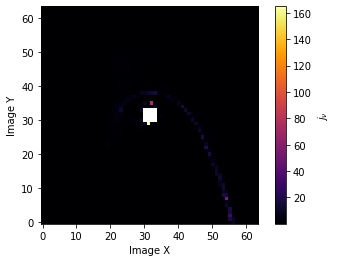

In [6]:
frequencies = np.array(hf['frequency'][9])
plt.imshow(hf['tau'][9],cmap='inferno',origin='lower')
plt.colorbar(label="$j_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

In [7]:
hf = np.load('../output/r1200_pinhole_tde1335_inc15.npz')

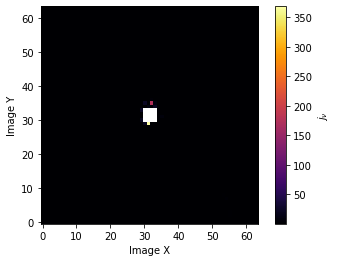

In [8]:
frequencies = np.array(hf['frequency'][9])
plt.imshow(hf['tau'][9],cmap='inferno',origin='lower')
plt.colorbar(label="$j_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

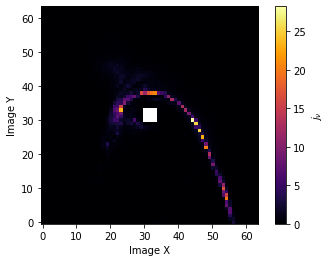

In [45]:
frequencies = np.array(hf['frequency'])
plt.imshow(hf['I_nu'],cmap='inferno',origin='lower')
plt.colorbar(label="$j_\\nu$")
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

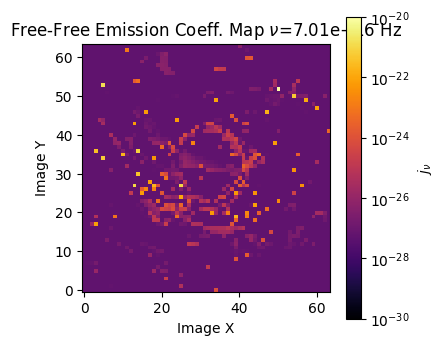

In [ ]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['emission'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-60
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-30))
plt.colorbar(label="$j_\\nu$")
plt.title('Free-Free Emission Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

In [15]:
hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc45_opacitytable.npz')

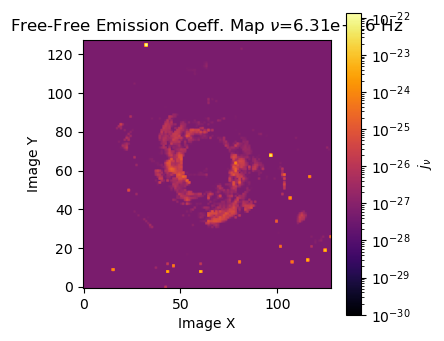

In [16]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['emission'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-60
i[i<minVal]=minVal

plt.imshow(i*(2.39e16)**2,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-30))
plt.colorbar(label="$j_\\nu$")
plt.title('Free-Free Emission Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

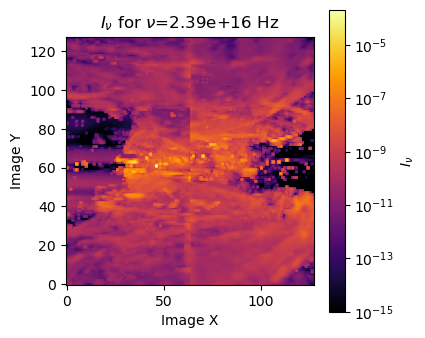

In [18]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-15
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('$I_\\nu$ for $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

the above image looks really ugly. I think that I should zoom out even more and also I should try to check different phi values/inc values. in particular it seems like the boundary out in front is weird.

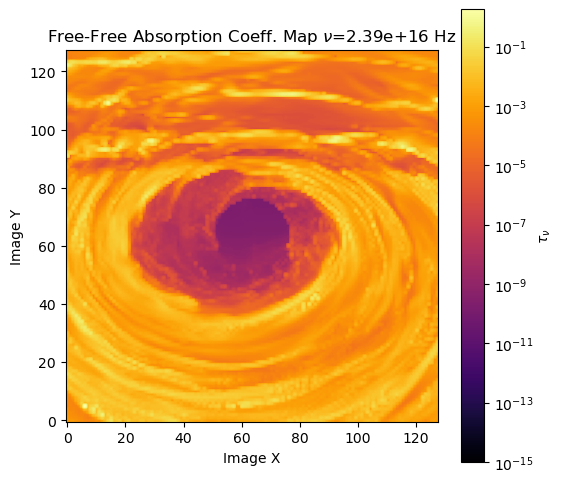

In [11]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-6
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['tau'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-15
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$\\tau_\\nu$")
plt.title('Free-Free Absorption Coeff. Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

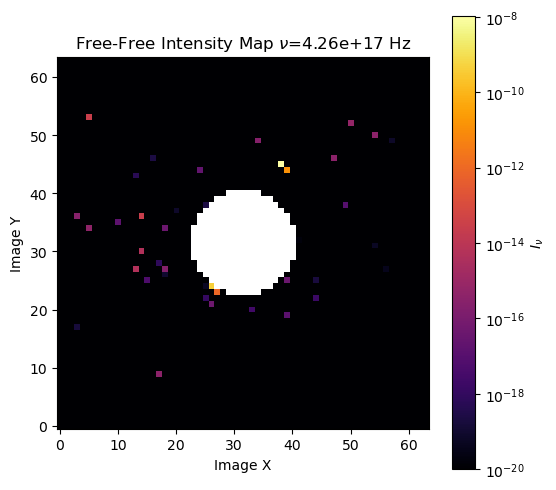

In [49]:
frequencies = np.array(hf['frequency'])
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal

plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

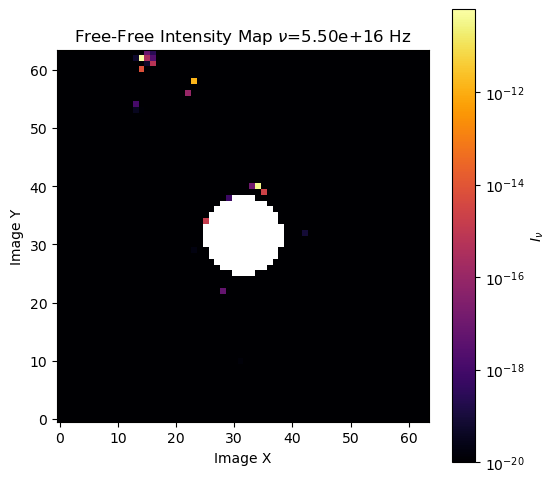

In [22]:
frequencies = np.array(hf['frequency'])

#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal
plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[0]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[0]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

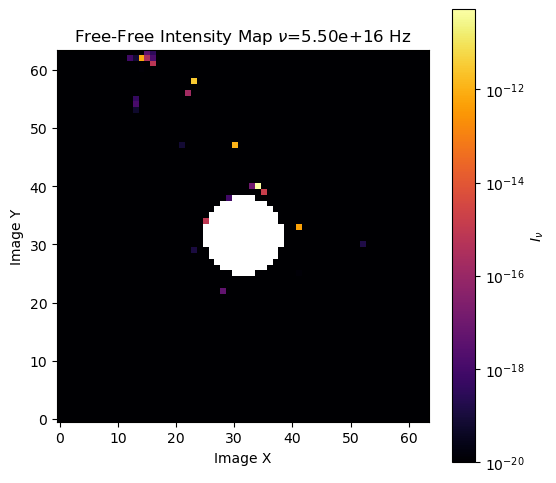

In [15]:
frequencies = np.array(r2hf['frequency'])

#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(r2hf['I_nu'])
#i'm going to have 1e-10 be the baseline min value
minVal = 1e-20
i[i<minVal]=minVal
plt.imshow(i,cmap='inferno',origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[0]), norm=colors.LogNorm(vmin=minVal))
plt.colorbar(label="$I_\\nu$")
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[0]))
plt.xlabel('Image X')
plt.ylabel('Image Y')
plt.show()

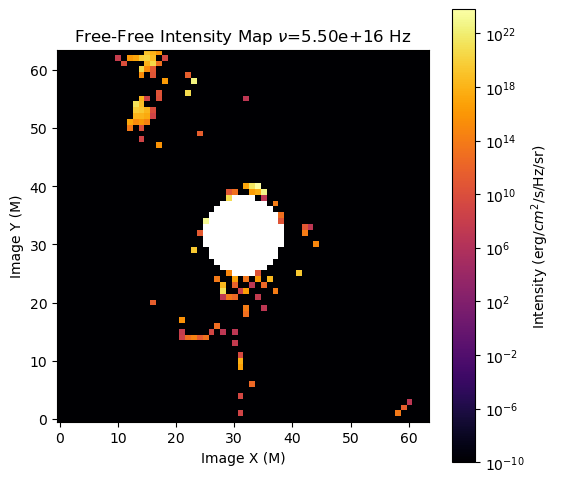

In [38]:
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

In [48]:
freq = len(frequencies)-3
print(np.nanmean(i))
print(np.nanmedian(i))

4.245919609251542e+21
1e-10


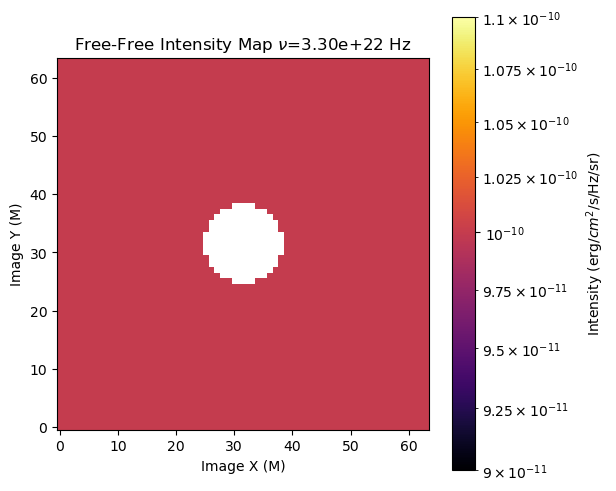

In [ ]:
freq = len(frequencies)-2
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(hf['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

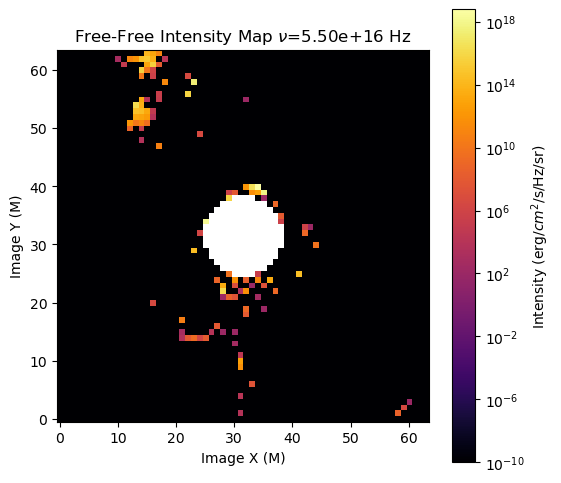

In [33]:
freq = len(frequencies)-5
#print(np.argwhere(np.isnan(temp['I_nu'][freq])==False).shape)
i = np.copy(temp['I_nu'][freq])
#i'm going to have 1e-10 be the baseline min value
i[i<1e-10]=1e-10
plt.imshow(i,cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm(vmin=1e-10))
plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
plt.xlabel('Image X (M)')
plt.ylabel('Image Y (M)')
plt.show()

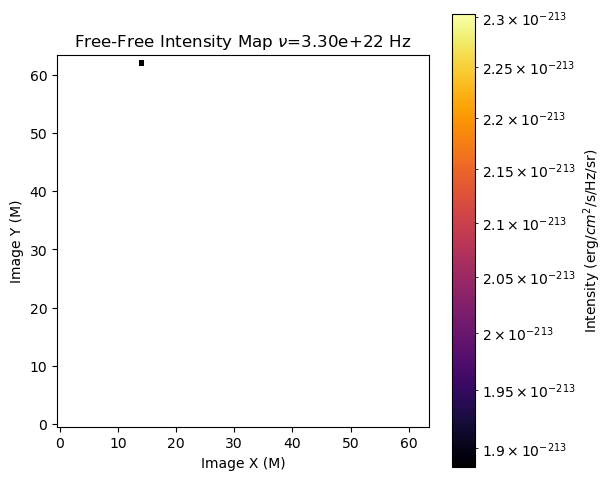

In [ ]:
for freq in range(len(frequencies)-1):
    plt.clf()
    plt.imshow(hf['I_nu'][freq],cmap='inferno', origin='lower', label="$\\nu$={0:.2e} Hz".format(frequencies[freq]), norm=colors.LogNorm())
    plt.colorbar(label='Intensity (erg/$cm^2$/s/Hz/sr)')
    plt.title('Free-Free Intensity Map $\\nu$={0:.2e} Hz'.format(frequencies[freq]))
    plt.xlabel('Image X (M)')
    plt.ylabel('Image Y (M)')
    #plt.show()
    plt.savefig('../plots/free_free_image_{0:.2e}Hz.png'.format(frequencies[freq]))

/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:446: UserWarning: Warning: converting a masked element to nan.
  dv = np.float64(self.norm.vmax) - np.float64(self.norm.vmin)
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:453: UserWarning: Warning: converting a masked element to nan.
  a_min = np.float64(newmin)
/home/tegan/anaconda3/envs/research/lib/python3.6/site-packages/matplotlib/image.py:458: UserWarning: Warning: converting a masked element to nan.
  a_max = np.float64(newmax)


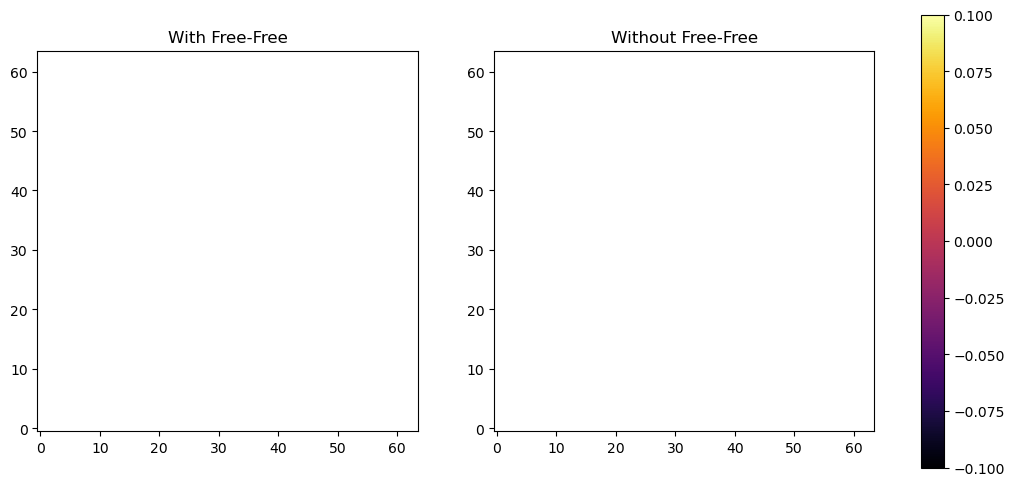

In [ ]:
fig,ax = plt.subplots(1,2,figsize=(12,6))
ax[0].imshow(hf['I_nu'][15], cmap='inferno', origin='lower',vmax=1e15)
ax[1].imshow(hs['I_nu'][0], cmap='inferno', origin='lower',vmax=1e-3)
ax[0].set_title('With Free-Free')
ax[1].set_title('Without Free-Free')
plt.colorbar(ax[1].images[0], ax=ax, fraction=0.05)
plt.show()

In [24]:
free['I_nu'][32,32]

8.411915668450402e-08

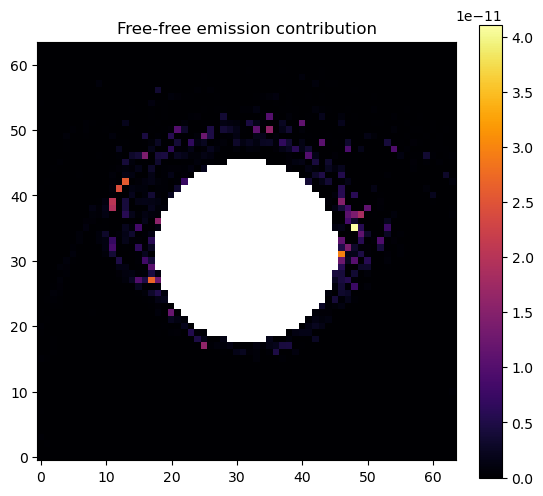

In [8]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['emission']-hs['emission'], cmap='inferno', origin='lower')
plt.colorbar(fraction=0.05)
plt.title('Free-free emission contribution')
plt.show()

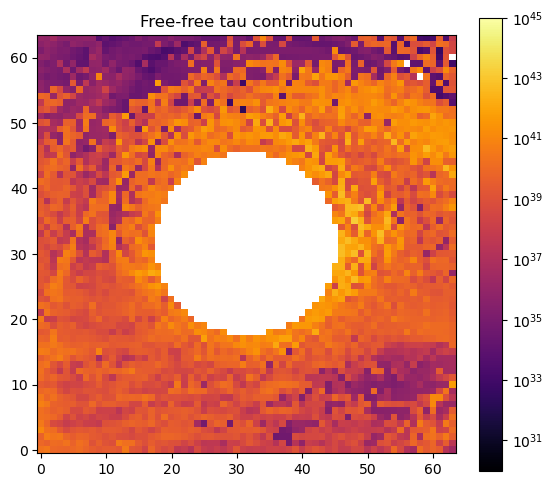

In [9]:
fig, ax = plt.subplots(1,1)
plt.imshow(hf['tau']-hs['tau'], cmap='inferno', origin='lower',norm=LogNorm(vmin=1e30, vmax=1e45))
plt.colorbar(fraction=0.05)
plt.title('Free-free tau contribution')
plt.show()

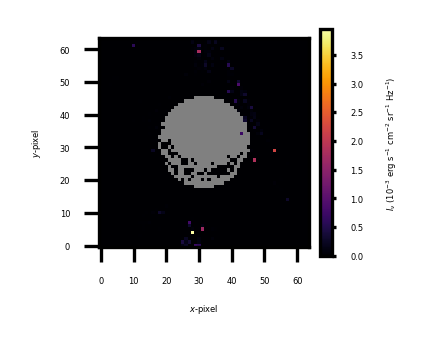

In [6]:
default_args['fontsize'] = (2)
default_args['figsize'] = (1,1)

fig,ax = utils.plot_data(**default_args)
#ax.margins(x=0,y=0)
plt.show()

# make spectrum

In [19]:
tabOpacity = np.load('../output/r1600_w800_pinhole_cbdisk_inc45_opacitytable.npz')
free = np.load('../output/r1600_w800_pinhole_cbdisk_inc45.npz')

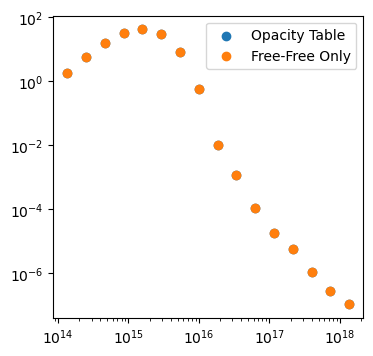

In [20]:
plt.scatter(tabOpacity['frequency'],np.sum(tabOpacity['I_nu'],axis=(1,2)),label='Opacity Table')
plt.scatter(free['frequency'],np.sum(free['I_nu'],axis=(1,2)),label='Free-Free Only')
plt.yscale('log')
plt.xscale('log')
plt.legend()
plt.show()

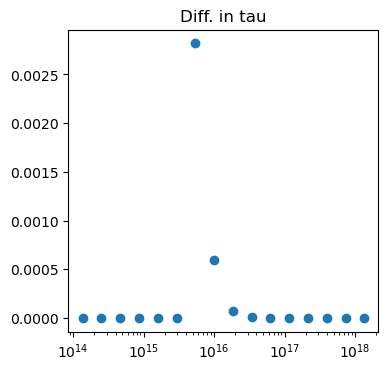

In [30]:
plt.scatter(tabOpacity['frequency'],np.sum(tabOpacity['tau'],axis=(1,2))-np.sum(free['tau'],axis=(1,2)))
plt.title('Diff. in tau')
plt.xscale('log')
plt.show()

# GRFP plots

In [4]:
2.68/1.88

1.4255319148936172

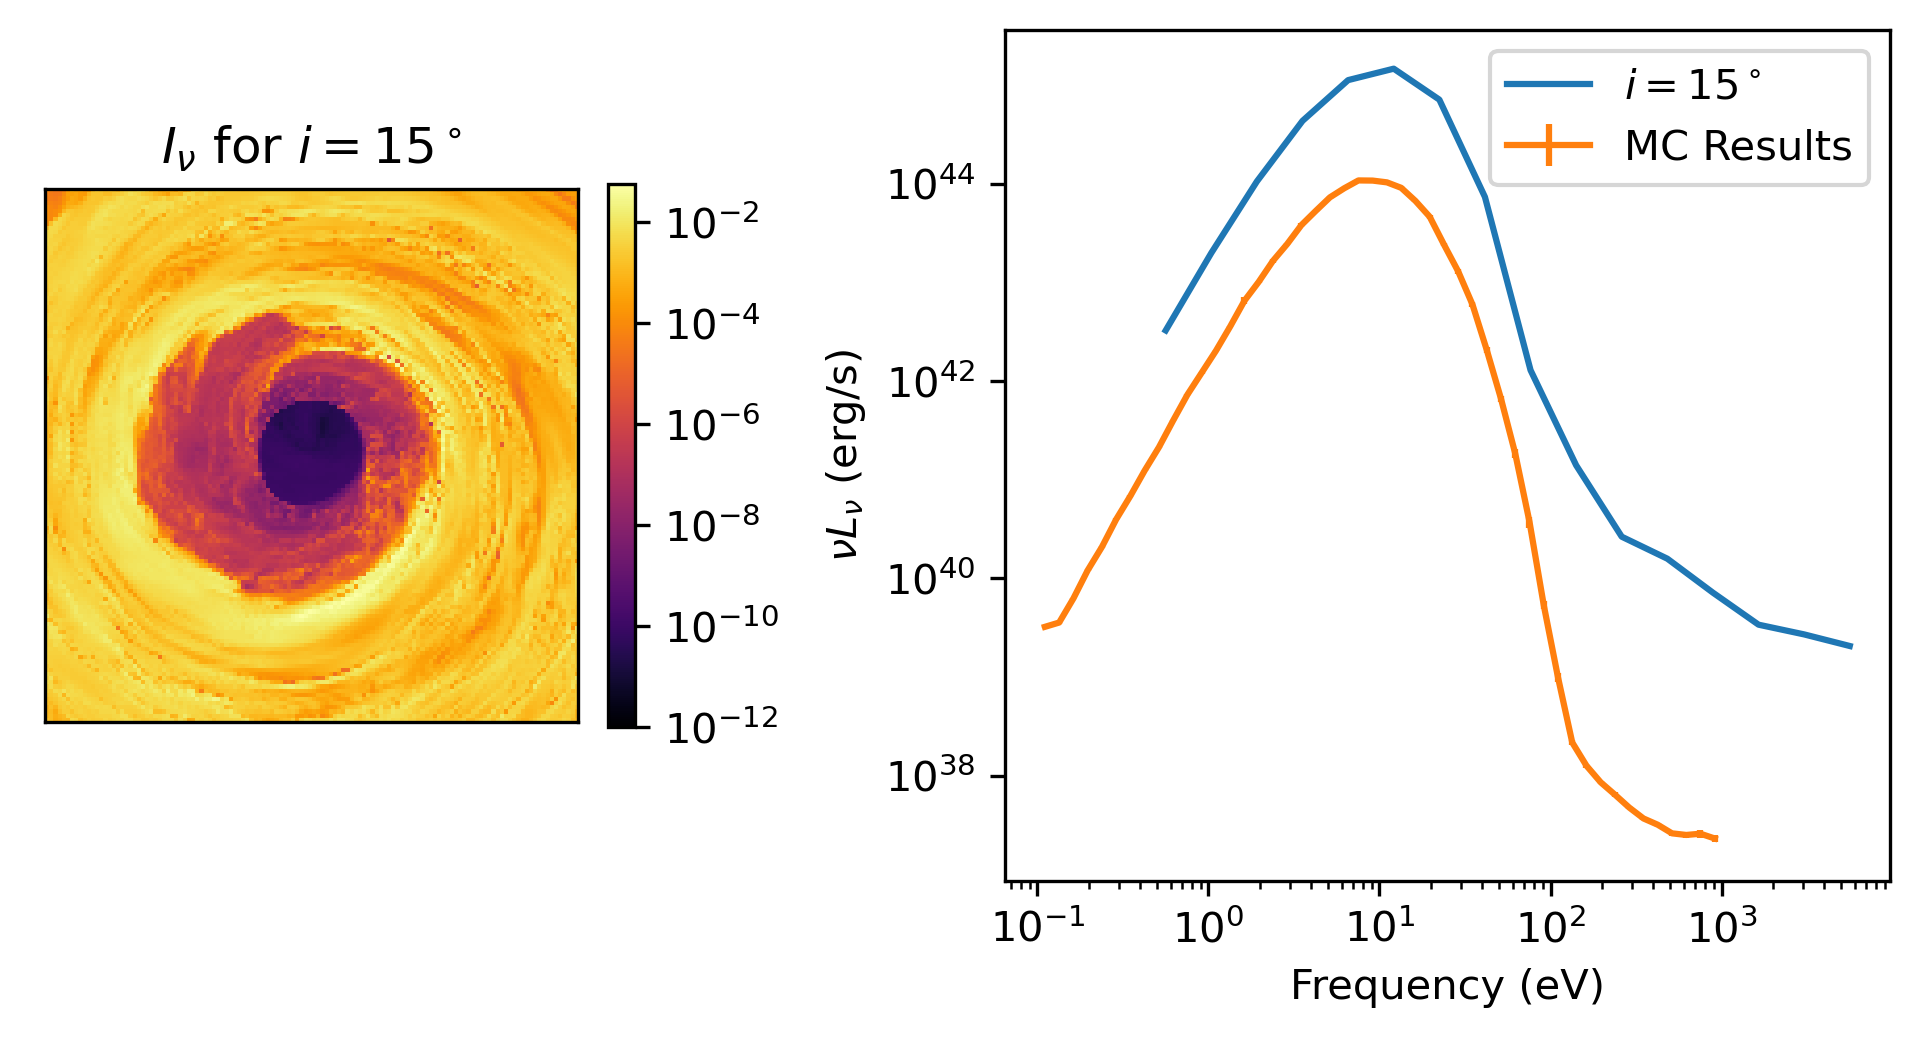

In [15]:
#2.68 width vs 1.88 height
h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc15.npz')
width = 3.25
height = 1.78
scale = 2
fig,axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [2, 3]}, figsize=(width*scale,height*scale),dpi=300)
minVal = 1e-12

im = axs[0].imshow(hf['I_nu'][4],cmap='inferno',origin='lower', norm=colors.LogNorm(vmin=minVal), extent=[-800,800,-800,800])
fig.colorbar(im, ax=axs[0], fraction=0.046)
axs[0].set_title('$I_\\nu$ for $i = 15^\\circ$')
axs[0].get_xaxis().set_visible(False)
axs[0].get_yaxis().set_visible(False)

argumentDict = {}
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc15.npz'
argumentDict['distance'] = 1600
argumentDict['mass'] = 2e7
argumentDict['frequency_num'] = 16
argumentDict['luminosity'] = True
argumentDict['inclination'] = 15.0
argumentDict['width'] = 800.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)
flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

axs[1].plot(freqs1*h_ev,freqs1*flux*eV,label='$i = 15^\\circ$')
shaneResults = np.loadtxt('../cbdisk_spectrum.txt')
axs[1].errorbar(shaneResults[:,0]*1e3,shaneResults[:,1],yerr=shaneResults[:,2],label='MC Results')
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Frequency (eV)')
axs[1].set_ylabel('$\\nu L_\\nu$ (erg/s)')
axs[1].set_aspect('auto')
plt.tight_layout()
plt.show()

In [ ]:
#2.68 width vs 1.88 height
h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

hf = np.load('../output/r1600_w800_pinhole_cbdisk_inc15.npz')
width = 3.25
height = 1.78
scale = 2
fig,axs = plt.subplots(1,2,gridspec_kw={'width_ratios': [2, 3]}, figsize=(width*scale,height*scale),dpi=300)
minVal = 1e-12

im = axs[0].imshow(hf['I_nu'][4],cmap='inferno',origin='lower', norm=colors.LogNorm(vmin=minVal), extent=[-800,800,-800,800])
fig.colorbar(im, ax=axs[0], fraction=0.046)
axs[0].set_title('$I_\\nu$ for $i = 15^\\circ$')
axs[0].get_xaxis().set_visible(False)
axs[0].get_yaxis().set_visible(False)

argumentDict = {}
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc15.npz'
argumentDict['distance'] = 1600
argumentDict['mass'] = 2e7
argumentDict['frequency_num'] = 16
argumentDict['luminosity'] = True
argumentDict['inclination'] = 15.0
argumentDict['width'] = 800.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)
flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

axs[1].plot(freqs1*h_ev,freqs1*flux*eV,label='$i = 15^\\circ$')
shaneResults = np.loadtxt('../cbdisk_spectrum.txt')
axs[1].errorbar(shaneResults[:,0]*1e3,shaneResults[:,1],yerr=shaneResults[:,2],label='MC Results')
axs[1].legend()
axs[1].set_xscale('log')
axs[1].set_yscale('log')
axs[1].set_xlabel('Frequency (eV)')
axs[1].set_ylabel('$\\nu L_\\nu$ (erg/s)')
axs[1].set_aspect('auto')
plt.tight_layout()
plt.show()

In [6]:
import matplotlib.font_manager
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

In [10]:
from matplotlib import RcParams
import matplotlib.pyplot as plt

latex_style_times = RcParams({'font.family': 'serif',
               'font.serif': ['Times'],
               'text.usetex': True,
               })

plt.style.use(latex_style_times)

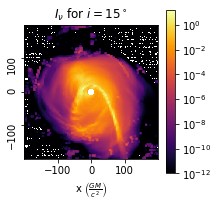

In [34]:

fig,ax = plt.subplots(1,1,figsize=(3,3))
minVal = 1e-12
from mpl_toolkits.axes_grid1 import make_axes_locatable

hf = np.load('../output/r1200_pinhole_tde1335_inc15.npz')
im = ax.imshow(hf['I_nu'][10],cmap='inferno',origin='lower', norm=colors.LogNorm(vmin=minVal), extent=[-200,200,-200,200])

fig.colorbar(im)
ax.set_title('$I_\\nu$ for $i = 15^\\circ$')
ax.set_xticks([-100,0,100])
ax.set_yticks([-100,0,100])
ax.tick_params("y",rotation=90)
ax.set_xlabel('x $\\left(\\frac{GM}{c^2}\\right)$')
#circ = Circle((0, 0), 140, color='white', fill=True,alpha=0.5)
#ax.add_patch(circ)
fig.savefig('../plots/tde1335_inc15_image.png', bbox_inches='tight', dpi=300)
plt.show()


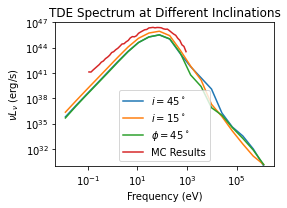

In [48]:

h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

fig,ax = plt.subplots(1,1,figsize=(4,3))
argumentDict = {}
argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc45.npz'
argumentDict['distance'] = 1200
argumentDict['mass'] = 3e6
argumentDict['frequency_num'] = 20
argumentDict['luminosity'] = True
argumentDict['inclination'] = 45.0
argumentDict['width'] = 400.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)


flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

ax.plot(freqs1*h_ev,freqs1*flux*eV,label='$i = 45^\\circ$')

argumentDict['inclination'] = 15.0
argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15.npz'
flux2, freqs2 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs2*h_ev,freqs2*flux*eV,label='$i = 15^\\circ$')


argumentDict['inclination'] = 45.0
argumentDict['filename_data'] = '../output/r800_pinhole_tde1335_phi45.npz'
flux3, freqs3 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux3*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs3*h_ev,freqs3*flux*eV,label='$\\phi = 45^\\circ$')

shaneResults = np.loadtxt('../spec.txt')
ax.plot(shaneResults[:,0]*h_ev,shaneResults[:,1]*1e3,label='MC Results')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_ylim(1e30,1e47)
ax.set_xlabel('Frequency (eV)')
ax.set_ylabel('$\\nu L_\\nu$ (erg/s)')
ax.set_title('TDE Spectrum at Different Inclinations')
plt.tight_layout()

fig.savefig('../plots/tde1335_spectrum.png', bbox_inches='tight', dpi=300)
ax.set_aspect('auto')

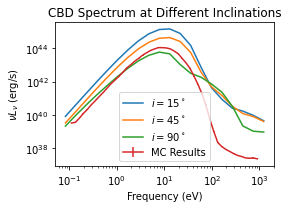

In [39]:

h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

fig,ax = plt.subplots(1,1,figsize=(4,3))
argumentDict = {}
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc15.npz'
argumentDict['distance'] = 1600
argumentDict['mass'] = 2e7
argumentDict['frequency_num'] = 16
argumentDict['luminosity'] = True
argumentDict['inclination'] = 15.0
argumentDict['width'] = 800.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)


flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

ax.plot(freqs1*h_ev,freqs1*flux*eV,label='$i = 15^\\circ$')

argumentDict['inclination'] = 45.0
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc45.npz'
flux2, freqs2 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs2*h_ev,freqs2*flux*eV,label='$i = 45^\\circ$')


argumentDict['inclination'] = 90.0
argumentDict['filename_data'] = '../output/r1600_w800_pinhole_cbdisk_inc90.npz'
flux3, freqs3 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux3*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs3*h_ev,freqs3*flux*eV,label='$i = 90^\\circ$')

shaneResults = np.loadtxt('../cbdisk_spectrum.txt')
ax.errorbar(shaneResults[:,0]*1e3,shaneResults[:,1],yerr=shaneResults[:,2],label='MC Results')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency (eV)')
ax.set_ylabel('$\\nu L_\\nu$ (erg/s)')
ax.set_title('CBD Spectrum at Different Inclinations')
plt.tight_layout()

fig.savefig('../plots/cbdisk_spectrum.png', bbox_inches='tight', dpi=300)
ax.set_aspect('auto')

## spectrum

RuntimeError: Only single frequency found in file.

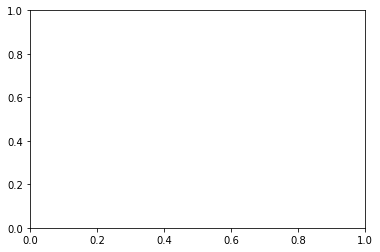

In [2]:

h_ev = 4.135667662e-15
eV = 1.60218e-12
c = 2.99792458e10
gg_msun = 1.32712440018e26

fig,ax = plt.subplots(1,1,figsize=(6,4))
argumentDict = {}
argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15_opacitytable_test.npz'
argumentDict['distance'] = 1200
argumentDict['mass'] = 3e6
argumentDict['frequency_num'] = 20
argumentDict['luminosity'] = True
argumentDict['inclination'] = 15.0
argumentDict['width'] = 200.0
argumentDict['max_level'] = None
argumentDict['adaptive_num_levels'] = None
rg = gg_msun * argumentDict['mass'] / (c ** 2)


flux1, freqs1 = sp.get_flux(**argumentDict)
#convert flux to luminosity
distance_cm = (argumentDict['distance']*rg)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux1*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))

ax.plot(freqs1,freqs1*flux*eV,label='w/ opacity table')

#argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15_opacitytable_test.npz'
#flux2, freqs2 = sp.get_flux(**argumentDict)
#thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
#flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
#ax.plot(freqs2,freqs2*flux*eV,label='free-free w/ interp')


argumentDict['filename_data'] = '../output/r1200_pinhole_tde1335_inc15.npz'
flux2, freqs2 = sp.get_flux(**argumentDict)
thetaWidth = (np.cos(np.radians(argumentDict['inclination'])-np.arctan(2*argumentDict['width']/argumentDict['distance']))-np.cos(np.radians(argumentDict['inclination'])+np.arctan(2*argumentDict['width']/argumentDict['distance'])))
flux = (flux2*4*np.pi*distance_cm**2)/(thetaWidth*np.arctan(2*argumentDict['width']/argumentDict['distance']))
ax.plot(freqs2,freqs2*flux*eV,label='w/o opacity table')

shaneResults = np.loadtxt('../spec.txt')
ax.plot(shaneResults[:,0],shaneResults[:,1]*1e3,label='MC Results')
ax.legend()
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('Frequency (Hz)')
ax.set_ylabel('$\\nu L_\\nu$ (eV/s)')
ax.set_title('TDE Spectrum at $i = 15^\\circ$')
plt.tight_layout()
plt.show()

In [ ]:
1e-3*1.602176634e-9/h
#2.417989 e 14

241798924208491.84

In [11]:
np.logspace(np.log10(5802.26),np.log10(1.16045e8),num=69)

array([5.80226000e+03, 6.71193305e+03, 7.76422381e+03, 8.98149176e+03,
       1.03896019e+04, 1.20184742e+04, 1.39027197e+04, 1.60823754e+04,
       1.86037556e+04, 2.15204355e+04, 2.48943899e+04, 2.87973097e+04,
       3.33121257e+04, 3.85347705e+04, 4.45762168e+04, 5.15648356e+04,
       5.96491236e+04, 6.90008590e+04, 7.98187510e+04, 9.23326622e+04,
       1.06808493e+05, 1.23553832e+05, 1.42924489e+05, 1.65332060e+05,
       1.91252671e+05, 2.21237090e+05, 2.55922440e+05, 2.96045728e+05,
       3.42459508e+05, 3.96149999e+05, 4.58258035e+05, 5.30103314e+05,
       6.13212429e+05, 7.09351317e+05, 8.20562771e+05, 9.49209857e+05,
       1.09802612e+06, 1.27017365e+06, 1.46931032e+06, 1.69966746e+06,
       1.96613978e+06, 2.27438939e+06, 2.63096609e+06, 3.04344656e+06,
       3.52059534e+06, 4.07255108e+06, 4.71104194e+06, 5.44963481e+06,
       6.30402361e+06, 7.29236270e+06, 8.43565269e+06, 9.75818666e+06,
       1.12880663e+07, 1.30577991e+07, 1.51049889e+07, 1.74731354e+07,
      